In [75]:
import numpy as np
import matplotlib.pylab as plt
import sys
sys.path.append("..")
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset


### $L^2$-projection models

In [76]:
from numpy.polynomial.legendre import leggauss
from scipy.interpolate import interp1d

from src.dg_utils import (
    eval_orthonormal_legendre_1d,
)

# ------------------------------------------------------------
# 1D helper: uniform sample grid (interpreted as pixel centers)
# ------------------------------------------------------------
def build_signal_grid_1d(N, xlim=(-1.0, 1.0)):
    """
    Build a uniform 1D sample grid of N cell centers on [xlim[0], xlim[1]].
    
    Returns
    -------
    xgrid : ndarray, shape (N,)
        Cell-center/sample locations.
    dx : float
        Grid spacing.
    """
    xmin, xmax = xlim
    dx = (xmax - xmin) / N
    xgrid = np.linspace(xmin + 0.5 * dx, xmax - 0.5 * dx, N)
    return xgrid, dx


# ------------------------------------------------------------
# 1D helper: DG mesh
# ------------------------------------------------------------
def build_dg_mesh_1d(num_samples, xlim=(-1.0, 1.0), deg=2):
    """
    Build a uniform 1D DG mesh with K elements such that
        num_samples = K * (deg + 1)
    """
    p = deg
    if num_samples % (p + 1) != 0:
        raise ValueError(
            f"num_samples={num_samples} must be divisible by deg+1={p+1}"
        )

    K = num_samples // (p + 1)
    xmin, xmax = xlim
    x_edges = np.linspace(xmin, xmax, K + 1)

    return {
        "K": K,
        "p": p,
        "xlim": xlim,
        "x_edges": x_edges,
    }


# ------------------------------------------------------------
# Continuous representations from sampled data
# ------------------------------------------------------------
def make_linear_function_1d(arr, xgrid, fill_value=0.0):
    """
    Interpret arr as point samples at xgrid and build a piecewise linear
    interpolant. Outside the sampled support, return fill_value.
    """
    arr = np.asarray(arr, dtype=float)
    xgrid = np.asarray(xgrid, dtype=float)

    interp = interp1d(
        xgrid,
        arr,
        kind="linear",
        bounds_error=False,
        fill_value=fill_value,
        assume_sorted=True,
    )

    def f(x):
        x = np.asarray(x)
        return np.asarray(interp(x), dtype=float)

    return f


def make_piecewise_constant_function_1d(arr, xgrid, fill_value=0.0):
    """
    Interpret arr as piecewise constant over cells centered at xgrid.
    Outside the covered support, return fill_value.
    """
    arr = np.asarray(arr, dtype=float)
    xgrid = np.asarray(xgrid, dtype=float)

    if len(xgrid) < 2:
        raise ValueError("Need at least 2 sample points.")

    dx = xgrid[1] - xgrid[0]
    xmin = xgrid[0] - 0.5 * dx
    xmax = xgrid[-1] + 0.5 * dx

    def f(x):
        x = np.asarray(x)
        out = np.full_like(x, fill_value, dtype=float)

        mask = (x >= xmin) & (x < xmax)
        if np.any(mask):
            ix = np.floor((x[mask] - xmin) / dx).astype(int)
            ix = np.clip(ix, 0, len(xgrid) - 1)
            out[mask] = arr[ix]

        return out

    return f


def make_sampled_function_1d(arr, xgrid, mode="linear", fill_value=0.0):
    """
    Construct a callable 1D function from sampled data.
    
    mode = "linear" or "piecewise_constant"
    """
    if mode == "linear":
        return make_linear_function_1d(arr, xgrid, fill_value=fill_value)
    elif mode == "piecewise_constant":
        return make_piecewise_constant_function_1d(arr, xgrid, fill_value=fill_value)
    else:
        raise ValueError(
            f'mode must be "linear" or "piecewise_constant", got {mode!r}'
        )


# ------------------------------------------------------------
# L2 projection onto 1D DG(P^p) modal basis
# ------------------------------------------------------------
def l2_project_samples_to_dg_1d(arr, xgrid, mesh, mode="linear", quad_order=None):
    """
    Compute the elementwise L2 projection of a 1D sampled-data representation
    onto a DG(P^p) modal basis.

    Parameters
    ----------
    arr : ndarray, shape (N,)
        Sample values.
    xgrid : ndarray, shape (N,)
        Sample locations (typically pixel centers).
    mesh : dict
        Must contain:
            - K
            - p
            - x_edges
    mode : str
        "linear" or "piecewise_constant"
    quad_order : int or None
        Quadrature order.

    Returns
    -------
    dg : dict
        DG modal representation with coeffs shape (K, p+1)
    """
    K = mesh["K"]
    p = mesh["p"]
    x_edges = mesh["x_edges"]

    if quad_order is None:
        quad_order = max(2 * p + 4, 8)

    f = make_sampled_function_1d(arr, xgrid, mode=mode, fill_value=0.0)

    rq, wq = leggauss(quad_order)                         # reference quad on [-1,1]
    phi_q = eval_orthonormal_legendre_1d(rq, p)          # shape (p+1, nq)

    coeffs = np.zeros((K, p + 1), dtype=float)

    for e in range(K):
        x0, x1 = x_edges[e], x_edges[e + 1]

        # Map quadrature nodes to physical element
        Xq = x0 + 0.5 * (x1 - x0) * (rq + 1.0)

        # Physical integral:
        # c_i = \int_{I_e} f(x) phi_i^phys(x) dx
        #
        # With orthonormal Legendre on the reference interval, if your
        # physical DG basis is the usual L2-normalized pullback
        # then the Jacobian factor cancels correctly depending on your
        # convention. This matches the style of your 2D code.
        Fq = f(Xq)                                        # shape (nq,)
        weighted_F = wq * Fq

        # Integrate against each basis function
        coeffs[e, :] = phi_q @ weighted_F

    return {
        "mesh": mesh,
        "coeffs": coeffs,
        "basis": "orthonormal_legendre_1d",
        "construction": "l2_projection",
        "representation_mode": mode,
        "quad_order": quad_order,
    }


# ------------------------------------------------------------
# Evaluate 1D DG modal solution on arbitrary points
# ------------------------------------------------------------
def eval_dg_modal_1d(dg, x):
    """
    Evaluate a 1D DG modal function at points x.

    Parameters
    ----------
    dg : dict
        Output from l2_project_samples_to_dg_1d
    x : ndarray
        Evaluation points

    Returns
    -------
    vals : ndarray
        DG values at x
    """
    x = np.asarray(x, dtype=float)

    mesh = dg["mesh"]
    coeffs = dg["coeffs"]
    K = mesh["K"]
    p = mesh["p"]
    x_edges = mesh["x_edges"]

    vals = np.zeros_like(x, dtype=float)

    for e in range(K):
        x0, x1 = x_edges[e], x_edges[e + 1]

        # include right endpoint only on last element
        if e < K - 1:
            mask = (x >= x0) & (x < x1)
        else:
            mask = (x >= x0) & (x <= x1)

        if not np.any(mask):
            continue

        # map physical x -> reference r in [-1,1]
        r = 2.0 * (x[mask] - x0) / (x1 - x0) - 1.0
        phi = eval_orthonormal_legendre_1d(r, p)   # shape (p+1, npts)

        vals[mask] = coeffs[e, :] @ phi

    return vals


# ------------------------------------------------------------
# Top-level wrapper
# ------------------------------------------------------------
def l2_project_signal_to_dg_1d(signal, xlim=(-1, 1), deg=2, mode="linear", quad_order=None):
    """
    Top-level wrapper analogous to your 2D function.

    Parameters
    ----------
    signal : ndarray, shape (N,)
        1D sampled signal.
    xlim : tuple
        Domain.
    deg : int
        DG polynomial degree.
    mode : str
        "linear" or "piecewise_constant"

    Returns
    -------
    dg : dict
        DG modal representation + metadata
    """
    arr = np.asarray(signal, dtype=float)
    if arr.ndim != 1:
        raise ValueError("Expected a 1D array for signal.")

    N = len(arr)
    xgrid, dx = build_signal_grid_1d(N, xlim=xlim)
    mesh = build_dg_mesh_1d(N, xlim=xlim, deg=deg)

    dg = l2_project_samples_to_dg_1d(
        arr, xgrid, mesh, mode=mode, quad_order=quad_order
    )

    dg["xgrid"] = xgrid
    dg["dx"] = dx

    return dg

### Nodal --> Modal model

In [77]:
import numpy as np

from src.dg_utils import eval_orthonormal_legendre_1d


def reference_nodes_equispaced_1d(p):
    """
    Return the p+1 equispaced reference nodes on [-1,1].
    """
    if not isinstance(p, int):
        raise TypeError("p must be an integer.")
    if p < 0:
        raise ValueError("p must be nonnegative.")

    if p == 0:
        return np.array([0.0], dtype=float)

    return np.linspace(-1.0, 1.0, p + 1, dtype=float)


def vandermonde_1d(nodes, p):
    """
    Build the Vandermonde matrix for the orthonormal Legendre basis
    evaluated at the given nodes.

    V[i,m] = phi_m(nodes[i])

    Returns
    -------
    V : ndarray, shape (p+1, p+1)
    Vinv : ndarray, shape (p+1, p+1)
    """
    L = eval_orthonormal_legendre_1d(nodes, p)  # shape (p+1, npts)
    V = L.T
    Vinv = np.linalg.inv(V)
    return V, Vinv


def nodal_to_modal_block_1d(u_block, Vinv):
    """
    Convert one local nodal block to modal coefficients.

    Parameters
    ----------
    u_block : ndarray, shape (p+1,)
        Local nodal values on one DG element.
    Vinv : ndarray, shape (p+1, p+1)

    Returns
    -------
    a_block : ndarray, shape (p+1,)
        Local modal coefficients.
    """
    u_block = np.asarray(u_block, dtype=float)
    return Vinv @ u_block


def modal_to_nodal_block_1d(a_block, V):
    """
    Convert one local modal block back to nodal values.
    """
    a_block = np.asarray(a_block, dtype=float)
    return V @ a_block


def nodal_signal_to_dg_1d(signal, xlim=(-1.0, 1.0), deg=2):
    """
    Interpret a 1D sampled signal as local nodal DG values and convert
    elementwise to modal DG coefficients.

    Parameters
    ----------
    signal : array_like, shape (N,)
        Input sampled data.
    xlim : tuple
        Physical domain limits.
    deg : int
        DG polynomial degree.

    Returns
    -------
    dg : dict
        DG modal representation and metadata.
    """
    arr = np.asarray(signal, dtype=float)

    if arr.ndim != 1:
        raise ValueError("Expected a 1D array for signal.")

    N = len(arr)
    p = deg
    order = p + 1

    if N % order != 0:
        raise ValueError(
            f"Signal length N={N} must be divisible by p+1={order}."
        )

    K = N // order
    x_edges = np.linspace(xlim[0], xlim[1], K + 1)

    # sample grid (same convention as before: cell-center global data grid)
    dx = (xlim[1] - xlim[0]) / N
    xgrid = np.linspace(xlim[0] + 0.5 * dx, xlim[1] - 0.5 * dx, N)

    # local reference nodes + Vandermonde
    nodes = reference_nodes_equispaced_1d(p)
    V, Vinv = vandermonde_1d(nodes, p)

    coeffs = np.zeros((K, order), dtype=float)

    blocks = arr.reshape(K, order)  # one nodal block per element
    for e in range(K):
        u_block = blocks[e, :]
        a_block = nodal_to_modal_block_1d(u_block, Vinv)
        coeffs[e, :] = a_block

    dg = {
        "mesh": {
            "K": K,
            "p": p,
            "order": order,
            "xlim": xlim,
            "x_edges": x_edges,
        },
        "coeffs": coeffs,
        "basis": "orthonormal_legendre_1d",
        "construction": "nodal_transform",
        "nodes_1d": nodes,
        "vandermonde_1d": V,
        "xgrid": xgrid,
        "dx": dx,
    }

    return dg


def eval_dg_modal_on_nodes_1d(dg):
    """
    Evaluate the 1D DG modal representation back on the elementwise nodal grid
    used in the nodal transform.

    Returns
    -------
    arr : ndarray, shape (N,)
        Reconstructed nodal values.
    """
    mesh = dg["mesh"]
    coeffs = dg["coeffs"]

    p = mesh["p"]
    K = mesh["K"]
    order = mesh["order"]

    nodes = dg.get("nodes_1d", reference_nodes_equispaced_1d(p))
    V, _ = vandermonde_1d(nodes, p)

    blocks = np.zeros((K, order), dtype=float)

    for e in range(K):
        a_block = coeffs[e, :]
        u_block = modal_to_nodal_block_1d(a_block, V)
        blocks[e, :] = u_block

    arr = blocks.reshape(K * order)
    return arr

In [78]:
def eval_nodal_interpolant_1d(signal, x, xlim=(-1.0, 1.0), deg=2):
    """
    Evaluate the elementwise nodal polynomial interpolant corresponding to
    the nodal -> modal interpretation.

    Parameters
    ----------
    signal : ndarray, shape (N,)
        Sampled signal, interpreted elementwise as nodal DG values.
    x : ndarray
        Evaluation points.
    xlim : tuple
        Domain limits.
    deg : int
        Polynomial degree p.

    Returns
    -------
    vals : ndarray
        Values of the elementwise nodal interpolant at x.
    """
    signal = np.asarray(signal, dtype=float)
    x = np.asarray(x, dtype=float)

    p = deg
    order = p + 1
    N = len(signal)

    if N % order != 0:
        raise ValueError(f"Signal length N={N} must be divisible by p+1={order}.")

    K = N // order
    x_edges = np.linspace(xlim[0], xlim[1], K + 1)

    # local nodal blocks
    blocks = signal.reshape(K, order)

    # reference nodes and Vandermonde
    nodes = reference_nodes_equispaced_1d(p)
    V, Vinv = vandermonde_1d(nodes, p)

    vals = np.zeros_like(x, dtype=float)

    for e in range(K):
        x0, x1 = x_edges[e], x_edges[e + 1]

        if e < K - 1:
            mask = (x >= x0) & (x < x1)
        else:
            mask = (x >= x0) & (x <= x1)

        if not np.any(mask):
            continue

        # local nodal values on this element
        u_block = blocks[e, :]

        # convert to modal coeffs for local evaluation
        a_block = Vinv @ u_block

        # map to reference element
        r = 2.0 * (x[mask] - x0) / (x1 - x0) - 1.0
        phi = eval_orthonormal_legendre_1d(r, p)   # shape (p+1, npts)

        vals[mask] = a_block @ phi

    return vals

In [79]:
def make_noisy_samples_1d(f_exact, N, xlim=(-1.0, 1.0), deg=2, seed=0, scale_sigma=1.0):
    """
    Sample f_exact on the 1D grid and add noise of size dx^(p+1).

    Returns
    -------
    xgrid : ndarray
    samples_clean : ndarray
    samples_noisy : ndarray
    dx : float
    sigma : float
    """
    
    xgrid, dx = build_signal_grid_1d(N, xlim=xlim)
    samples_clean = f_exact(xgrid)

    print(f"dx = {dx}")
    
    rng = np.random.default_rng(seed)
    sigma = dx ** (deg + 1)
    
    sigma = scale_sigma * sigma
    print(f"Noise level sigma = {sigma}")
    noise = sigma * rng.standard_normal(N)

    samples_noisy = samples_clean + noise
    return xgrid, samples_clean, samples_noisy, dx, sigma

In [80]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

def add_zoom_inset(ax, x, curves, labels, zoom_xlim, zoom_ylim=None):
    """
    Add a zoomed inset to an existing axis.

    Parameters
    ----------
    ax : matplotlib axis
    x : array
        x-coordinates
    curves : list of arrays
        y-values to plot
    labels : list of str
        labels (optional, can be None)
    zoom_xlim : tuple
        (xmin, xmax) for zoom region
    zoom_ylim : tuple or None
        if None, auto-determined
    """

    # Create inset axis
    axins = inset_axes(ax, width="35%", height="35%", loc="upper right")

    # Plot same curves in inset
    for y, label in zip(curves, labels):
        axins.plot(x, y)

    # Set zoom region
    axins.set_xlim(*zoom_xlim)

    if zoom_ylim is not None:
        axins.set_ylim(*zoom_ylim)
    else:
        # auto ylim based on zoom window
        mask = (x >= zoom_xlim[0]) & (x <= zoom_xlim[1])
        ymin = min(y[mask].min() for y in curves)
        ymax = max(y[mask].max() for y in curves)
        margin = 0.1 * (ymax - ymin + 1e-14)
        axins.set_ylim(ymin - margin, ymax + margin)

    axins.grid(True)

    # Draw box + connectors
    mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

    return axins

In [81]:
from src.siac_modal import local_pixel_center_nodes, siac_cgam, grab_integrals

def pad_modal_coeffs_1d(coeffs, pad):
    """
    Zero-pad 1D modal DG coefficients in element space.

    Parameters
    ----------
    coeffs : ndarray, shape (K, order)
        Modal DG coefficients.
    pad : int
        Number of ghost elements on each side.

    Returns
    -------
    out : ndarray, shape (K + 2*pad, order)
    """
    K, order = coeffs.shape
    out = np.zeros((K + 2 * pad, order), dtype=coeffs.dtype)
    out[pad:pad + K, :] = coeffs
    return out


def apply_siac_modal_dg_1d(dg, moments=None, BSorder=None, return_debug=False):
    """
    Apply the SIAC filter to a 1D modal DG solution.

    Parameters
    ----------
    dg : dict
        1D DG representation with keys:
            - "mesh"
            - "coeffs"
            - "xgrid"
            - "dx"
    moments : int or None
        Number of reproduced moments. Defaults to 2*p.
    BSorder : int or None
        B-spline order. Defaults to p+1.
    return_debug : bool
        If True, also return intermediate SIAC objects.

    Returns
    -------
    ustar_grid : ndarray, shape (K*order,)
        SIAC-filtered values on the elementwise nodal/image grid.
    debug : dict, optional
        Returned only if return_debug=True.
    """
    mesh = dg["mesh"]
    coeffs = dg["coeffs"]

    p = mesh["p"]
    order = p + 1
    K = mesh["K"]

    if moments is None:
        moments = 2 * p
    if BSorder is None:
        BSorder = p + 1

    # evaluation nodes on reference element
    nodes = local_pixel_center_nodes(order)

    # B-spline support information
    BSknots = np.linspace(-BSorder / 2, BSorder / 2, BSorder + 1)
    BSsupport = np.array(
        [np.floor(BSknots[0]), np.ceil(BSknots[-1])],
        dtype=int
    )
    BSlen = int(BSsupport[1] - BSsupport[0] + 1)

    # SIAC coefficients
    cgam = siac_cgam(moments, BSorder)

    # 1D integral blocks
    BSInt = grab_integrals(
        eval_nodes=nodes,
        p=p,
        BSorder=BSorder,
        BSsupport=BSsupport
    )  # shape (order, BSlen, order)

    kernellength = int(2 * np.ceil((moments + BSorder) / 2) + 1)
    halfker = int(np.ceil((moments + BSorder) / 2))

    # Build 1D SIAC matrix
    # SIACmatrix[m, r, k]
    # m = modal basis index
    # r = element shift in stencil
    # k = evaluation node index
    SIACmatrix = np.zeros((order, kernellength, order), dtype=float)

    for k in range(order):
        for igam in range(moments + 1):
            SIACmatrix[:, igam:igam + BSlen, k] += cgam[igam] * BSInt[:, :, k]

    # pad modal coefficients in element direction
    pad = halfker + 1
    coeffs_pad = pad_modal_coeffs_1d(coeffs, pad=pad)

    # filtered values on each original element/node
    ustar = np.zeros((K, order), dtype=float)

    for e in range(K):
        ce = e + pad

        # local block from padded coeffs
        block = coeffs_pad[ce - halfker : ce + halfker + 1, :]   # shape (kernellength, order)

        for k in range(order):
            S = SIACmatrix[:, :, k]   # shape (order, kernellength)

            # S[m,r] * block[r,m]
            val = np.einsum('mr,rm->', S, block)
            ustar[e, k] = val

    # flatten back to the image/nodal grid ordering
    ustar_grid = ustar.reshape(K * order)

    if return_debug:
        debug = {
            "nodes": nodes,
            "cgam": cgam,
            "BSsupport": BSsupport,
            "BSlen": BSlen,
            "BSInt": BSInt,
            "SIACmatrix": SIACmatrix,
            "kernellength": kernellength,
            "halfker": halfker,
            "pad": pad,
            "ustar_elementwise": ustar,
        }
        return ustar_grid, debug

    return ustar_grid

In [82]:
def apply_siac_modal_dg_1d_on_grid(dg, x_eval, moments=None, BSorder=None, quad_order=None):
    """
    Evaluate the 1D SIAC postprocessed DG solution directly on an arbitrary grid.
    """
    x_eval = np.asarray(x_eval, dtype=float)

    mesh   = dg["mesh"]
    coeffs = np.asarray(dg["coeffs"], dtype=float)

    p       = mesh["p"]
    order   = p + 1
    K       = mesh["K"]
    x_edges = mesh["x_edges"]

    if moments is None:
        moments = 2 * p
    if BSorder is None:
        BSorder = p + 1

    # B-spline support
    BSknots   = np.linspace(-BSorder / 2, BSorder / 2, BSorder + 1)
    BSsupport = np.array([np.floor(BSknots[0]), np.ceil(BSknots[-1])], dtype=int)
    BSlen     = int(BSsupport[1] - BSsupport[0] + 1)

    cgam = np.asarray(siac_cgam(moments, BSorder), dtype=float)

    # Exact length implied by the SIAC shift assembly
    kernellength = moments + BSlen
    halfker = kernellength // 2

    # Sanity check: should match number of SIAC coefficients
    if cgam.shape[0] != moments + 1:
        raise ValueError(
            f"siac_cgam returned {cgam.shape[0]} coefficients, expected {moments+1}"
        )

    # Pad DG coefficients so block = coeffs_pad[e : e+kernellength] is always valid
    pad = halfker
    coeffs_pad = pad_modal_coeffs_1d(coeffs, pad=pad)

    ustar = np.zeros_like(x_eval, dtype=float)

    for e in range(K):
        x0, x1 = x_edges[e], x_edges[e + 1]

        if e < K - 1:
            mask = (x_eval >= x0) & (x_eval < x1)
        else:
            mask = (x_eval >= x0) & (x_eval <= x1)

        if not np.any(mask):
            continue

        x_loc = x_eval[mask]
        zeta = 2.0 * (x_loc - x0) / (x1 - x0) - 1.0
        nloc = zeta.size

        BSInt = np.asarray(
            grab_integrals(
                eval_nodes=zeta,
                p=p,
                BSorder=BSorder,
                BSsupport=BSsupport,
                quad_order=quad_order,
            ),
            dtype=float,
        )

        # Enforce 3D shape: (order, BSlen, nloc)
        if BSInt.ndim == 2:
            BSInt = BSInt[:, :, None]

        if BSInt.shape != (order, BSlen, nloc):
            raise ValueError(
                f"grab_integrals returned shape {BSInt.shape}, "
                f"expected {(order, BSlen, nloc)}"
            )

        # SIACmatrix shape: (order, kernellength, nloc)
        SIACmatrix = np.zeros((order, kernellength, nloc), dtype=float)

        # Vectorized over local evaluation points
        for igam, cg in enumerate(cgam):
            SIACmatrix[:, igam:igam + BSlen, :] += cg * BSInt

        # DG block contributing to this element's SIAC evaluation
        # shape: (kernellength, order)
        block = coeffs_pad[e : e + kernellength, :]

        if block.shape != (kernellength, order):
            raise ValueError(
                f"Coefficient block has shape {block.shape}, "
                f"expected {(kernellength, order)}"
            )

        # vals[n] = sum_{m,r} SIACmatrix[m,r,n] * block[r,m]
        vals = np.einsum("mrn,rm->n", SIACmatrix, block)

        ustar[mask] = vals

    return ustar

In [83]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

def plot_1d_representations_from_noisy_samples(
    f_exact,
    samples_noisy,
    COLORS,
    xlim=(-1.0, 1.0),
    deg=2,
    nplot=1000,
    figsize=(10, 8),
    zoom_xlim=None,
    zoom_location=None
):
    samples_noisy = np.asarray(samples_noisy, dtype=float)
    N = len(samples_noisy)

    xgrid, dx = build_signal_grid_1d(N, xlim=xlim)
    xf = np.linspace(xlim[0], xlim[1], nplot)

    f_lin = make_linear_function_1d(samples_noisy, xgrid, fill_value=0.0)
    f_pc = make_piecewise_constant_function_1d(samples_noisy, xgrid, fill_value=0.0)
    f_nodal = eval_nodal_interpolant_1d(samples_noisy, xf, xlim=xlim, deg=deg)

    fig, axs = plt.subplots(3, 1, figsize=figsize, sharex=True)

    # ---------------- Top ----------------
    axs[0].plot(xf, f_exact(xf), linewidth=2, label="Exact", color=COLORS["exact"])
    axs[0].plot(xgrid, samples_noisy, ".", label="Noisy samples", color=COLORS["samples"])
    axs[0].set_title("Noisy sampled data")
    axs[0].grid(True)
    axs[0].legend(fontsize=9, loc="upper left")

    # ---------------- Middle ----------------
    axs[1].plot(xf, f_exact(xf), linewidth=2, label="Exact", color=COLORS["exact"])
    axs[1].plot(xgrid, samples_noisy, ".", label="Noisy samples", color=COLORS["samples"])
    axs[1].plot(xf, f_lin(xf), "--", label="Linear interpolant", color=COLORS["linear"])
    axs[1].plot(xf, f_pc(xf), "-.", label="Piecewise constant model", color=COLORS["piecewise"])
    axs[1].set_title("Representations used for L2 projection")
    axs[1].grid(True)
    axs[1].legend(fontsize=9, loc="upper left")

    # ---------------- Bottom ----------------
    axs[2].plot(xf, f_exact(xf), linewidth=2, label="Exact", color=COLORS["exact"])
    axs[2].plot(xgrid, samples_noisy, ".", label="Noisy samples", color=COLORS["samples"])
    axs[2].plot(xf, f_nodal, label="Elementwise nodal polynomial", color=COLORS["nodal"])
    axs[2].set_title("Nodal DG interpretation")
    axs[2].grid(True)
    axs[2].legend(fontsize=9, loc="upper left")
    axs[2].set_xlabel("x")

    # ---------------- ZOOM FOR ALL ----------------
    if zoom_xlim is not None:
        for i, ax in enumerate(axs):

            axins = inset_axes(ax, width="35%", height="35%", loc=zoom_location, borderpad=1.8)

            # plot appropriate curves
            axins.plot(xf, f_exact(xf), color=COLORS["exact"])
            axins.plot(xgrid, samples_noisy, ".", color=COLORS["samples"])

            if i == 1:
                axins.plot(xf, f_lin(xf), color=COLORS["linear"])
                axins.plot(xf, f_pc(xf), color=COLORS["piecewise"])
            elif i == 2:
                axins.plot(xf, f_nodal, color=COLORS["nodal"])

            axins.set_xlim(*zoom_xlim)

            # auto y-limits
            mask = (xf >= zoom_xlim[0]) & (xf <= zoom_xlim[1])

            ymin = f_exact(xf)[mask].min()
            ymax = f_exact(xf)[mask].max()

            if i == 1:
                ymin = min(ymin, f_lin(xf)[mask].min(), f_pc(xf)[mask].min())
                ymax = max(ymax, f_lin(xf)[mask].max(), f_pc(xf)[mask].max())
            elif i == 2:
                ymin = min(ymin, f_nodal[mask].min())
                ymax = max(ymax, f_nodal[mask].max())

            margin = 0.1 * (ymax - ymin + 1e-14)
            axins.set_ylim(ymin - margin, ymax + margin)

            axins.grid(False)

            # draw box (only once is enough visually, but ok per axis)
            mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

    fig.tight_layout()
    return fig, axs

In [84]:
def plot_1d_dg_representations(
    f_exact,
    samples_noisy,
    COLORS,
    xlim=(-1.0, 1.0),
    deg=2,
    quad_order=None,
    nplot=1000,
    figsize=(10, 6),
    zoom_xlim=None,
    zoom_location=None
):
    samples_noisy = np.asarray(samples_noisy, dtype=float)
    xf = np.linspace(xlim[0], xlim[1], nplot)

    dg_lin = l2_project_signal_to_dg_1d(
        samples_noisy, xlim=xlim, deg=deg, mode="linear", quad_order=quad_order
    )
    dg_pc = l2_project_signal_to_dg_1d(
        samples_noisy, xlim=xlim, deg=deg, mode="piecewise_constant", quad_order=quad_order
    )
    dg_nodal = nodal_signal_to_dg_1d(
        samples_noisy, xlim=xlim, deg=deg
    )

    u_lin = eval_dg_modal_1d(dg_lin, xf)
    u_pc = eval_dg_modal_1d(dg_pc, xf)
    u_nodal = eval_dg_modal_1d(dg_nodal, xf)

    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(xf, f_exact(xf), linewidth=2, label="Exact", color=COLORS["exact"])
    ax.plot(xf, u_lin, label="DG: linear -> L2", color=COLORS["linear"])
    ax.plot(xf, u_pc, label="DG: piecewise constant -> L2", color=COLORS["piecewise"])
    ax.plot(xf, u_nodal, label="DG: nodal -> modal", color=COLORS["nodal"])

    xgrid, _ = build_signal_grid_1d(len(samples_noisy), xlim=xlim)
    ax.plot(xgrid, samples_noisy, ".", label="Noisy samples", color=COLORS["samples"])

    ax.set_title("DG representations from different data interpretations")
    ax.set_xlabel("x")
    ax.grid(True)
    ax.legend(fontsize=9, loc="upper left")

    # ------------------ ZOOM PART ------------------
    if zoom_xlim is not None:
        axins = inset_axes(ax, width="35%", height="35%", loc=zoom_location, borderpad=1.8)

        # plot same curves
        axins.plot(xf, f_exact(xf), color=COLORS["exact"])
        axins.plot(xf, u_lin, color=COLORS["linear"])
        axins.plot(xf, u_pc, color=COLORS["piecewise"])
        axins.plot(xf, u_nodal, color=COLORS["nodal"])
        axins.plot(xgrid, samples_noisy, ".", color=COLORS["samples"])

        # zoom region
        axins.set_xlim(*zoom_xlim)

        # auto y-limits
        mask = (xf >= zoom_xlim[0]) & (xf <= zoom_xlim[1])
        ymin = min(
            f_exact(xf)[mask].min(),
            u_lin[mask].min(),
            u_pc[mask].min(),
            u_nodal[mask].min(),
        )
        ymax = max(
            f_exact(xf)[mask].max(),
            u_lin[mask].max(),
            u_pc[mask].max(),
            u_nodal[mask].max(),
        )
        margin = 0.1 * (ymax - ymin + 1e-14)
        axins.set_ylim(ymin - margin, ymax + margin)

        axins.grid(False)

        # draw box
        mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")
    # --------------------------------------------------

    fig.tight_layout()

    return fig, ax, {
        "linear_l2": dg_lin,
        "piecewise_constant_l2": dg_pc,
        "nodal_modal": dg_nodal,
    }

In [85]:
def plot_1d_siac_representations(
    f_exact,
    dg_dict,
    COLORS,
    xlim=(-1.0, 1.0),
    nplot=2000,
    figsize=(10, 6),
    moments=None,
    BSorder=None,
    zoom_xlim=None,
    zoom_location=None
):
    xf = np.linspace(xlim[0], xlim[1], nplot)

    ustar_lin = apply_siac_modal_dg_1d_on_grid(
        dg_dict["linear_l2"], xf, moments=moments, BSorder=BSorder
    )
    ustar_pc = apply_siac_modal_dg_1d_on_grid(
        dg_dict["piecewise_constant_l2"], xf, moments=moments, BSorder=BSorder
    )
    ustar_nodal = apply_siac_modal_dg_1d_on_grid(
        dg_dict["nodal_modal"], xf, moments=moments, BSorder=BSorder
    )

    xgrid = dg_dict["linear_l2"]["xgrid"]

    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(xf, f_exact(xf), linewidth=2, label="Exact", color=COLORS["exact"])
    ax.plot(xf, ustar_lin, label="SIAC: linear -> L2", color=COLORS["linear"])
    ax.plot(xf, ustar_pc, label="SIAC: piecewise constant -> L2", color=COLORS["piecewise"])
    ax.plot(xf, ustar_nodal, label="SIAC: nodal -> modal", color=COLORS["nodal"])

    ax.set_title("SIAC postprocessed DG representations")
    ax.set_xlabel("x")
    ax.grid(True)
    ax.legend(fontsize=9, loc="upper left")

    # ------------------ ZOOM PART ------------------
    if zoom_xlim is not None:
        axins = inset_axes(ax, width="35%", height="35%", loc=zoom_location, borderpad=1.8)

        axins.plot(xf, f_exact(xf), color=COLORS["exact"])
        axins.plot(xf, ustar_lin, color=COLORS["linear"])
        axins.plot(xf, ustar_pc, color=COLORS["piecewise"])
        axins.plot(xf, ustar_nodal, color=COLORS["nodal"])
        
        # can make this zoom smaller
        factor = 1.0    # larger here --> more zoom
        zoom_center = (zoom_xlim[0] + zoom_xlim[1]) / 2
        zoom_offset = np.abs(zoom_center - zoom_xlim[0]) / factor 
        zoom_xlim = (zoom_center - zoom_offset, zoom_center + zoom_offset)
        axins.set_xlim(*zoom_xlim)

        # auto y-limits
        mask = (xf >= zoom_xlim[0]) & (xf <= zoom_xlim[1])
        ymin = min(
            ustar_lin[mask].min(),
            ustar_pc[mask].min(),
            ustar_nodal[mask].min(),
        )
        ymax = max(
            ustar_lin[mask].max(),
            ustar_pc[mask].max(),
            ustar_nodal[mask].max(),
        )
        margin = 0.1 * (ymax - ymin + 1e-14)
        axins.set_ylim(ymin - margin, ymax + margin)

        axins.grid(False)

        mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")
    # --------------------------------------------------

    fig.tight_layout()

    return fig, ax, {
        "linear_l2": ustar_lin,
        "piecewise_constant_l2": ustar_pc,
        "nodal_modal": ustar_nodal,
        "xgrid": xgrid,
    }

dx = 0.03125
Noise level sigma = 0.003015782985847835


/tmp/ipykernel_61710/1780534351.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/tmp/ipykernel_61710/232270988.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/tmp/ipykernel_61710/1026484494.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


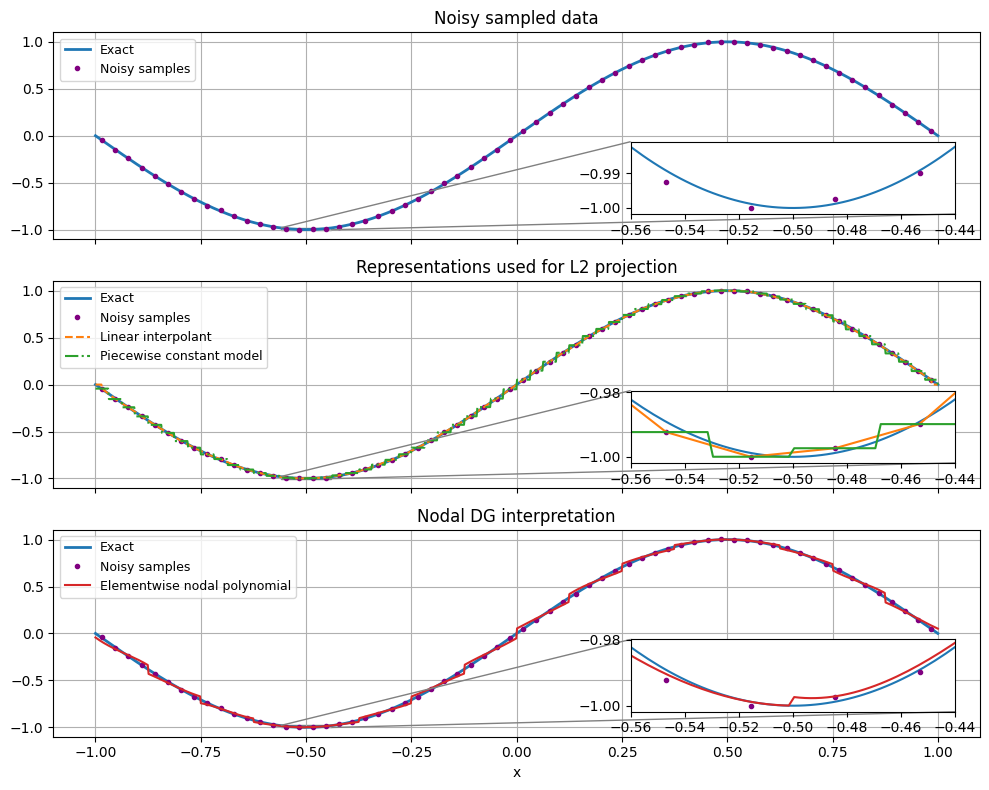

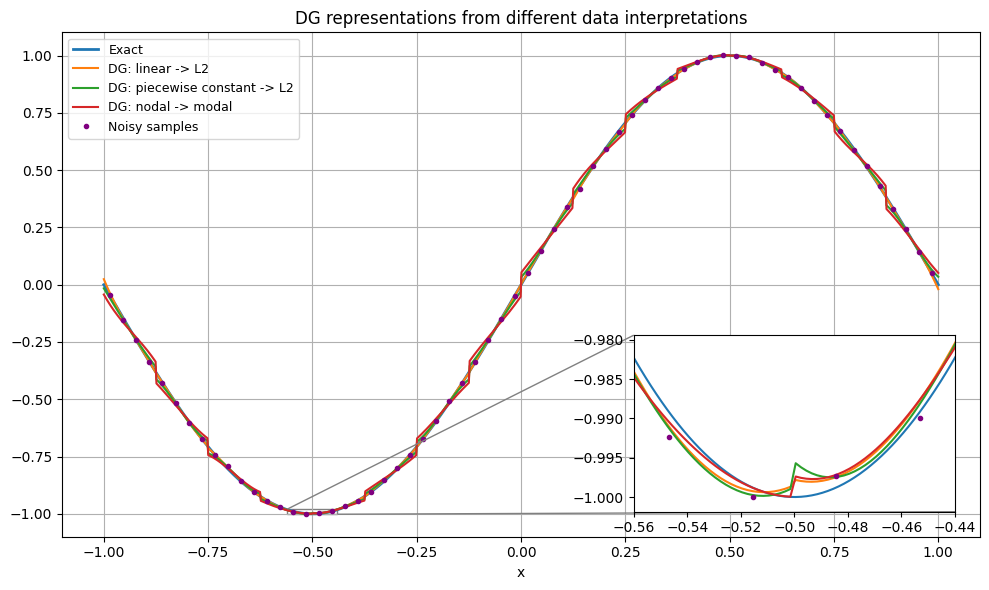

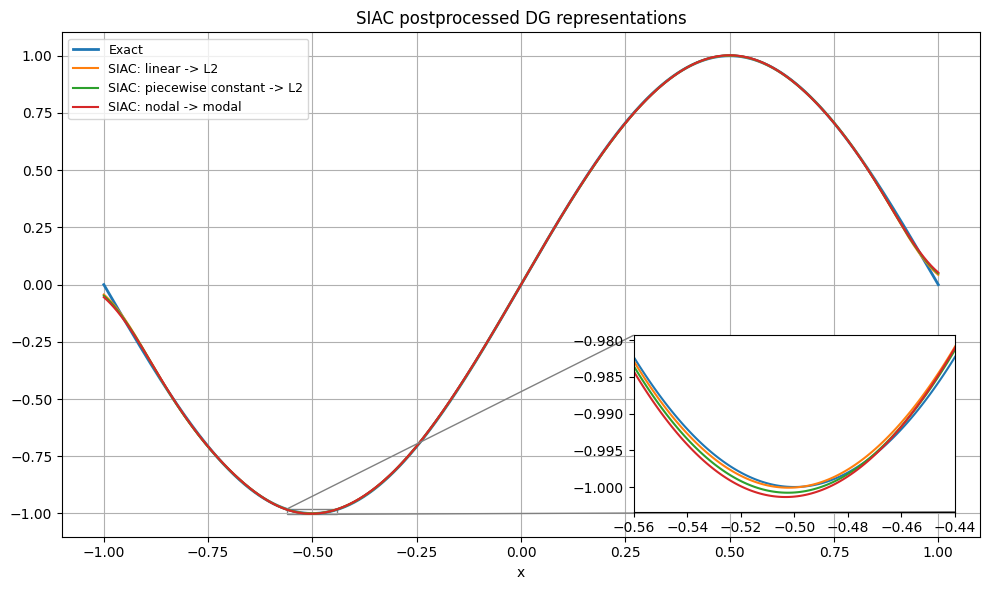

In [86]:
# exact function
def f_exact(x):
    return np.sin(np.pi*x)
    #return np.exp(-30.0 * (x - 0.35)**2) + 0.15 * np.sin(2*np.pi*x)

# setup
p = 3
K = 16
N = K * (p + 1)
xlim = (-1.0, 1.0)

# noisy data
scale_sigma = 10**3.5

xgrid, samples_clean, samples_noisy, dx, sigma = make_noisy_samples_1d(
    f_exact, N, xlim=xlim, deg=p, seed=3, scale_sigma=scale_sigma
)

COLORS = {
    "exact": "tab:blue",
    "samples": "purple",
    "linear": "tab:orange",
    "piecewise": "tab:green",
    "nodal": "tab:red",
}

center_zoom = -0.5
offset_zoom = 0.06
zoom = (center_zoom - offset_zoom, center_zoom + offset_zoom)
zoom_location = "lower right"

# figure 1
fig1, axs1 = plot_1d_representations_from_noisy_samples(
    f_exact,
    samples_noisy,
    COLORS=COLORS,
    xlim=xlim,
    deg=p,
    zoom_xlim=zoom,
    zoom_location=zoom_location
)


fig2, ax2, dg_dict = plot_1d_dg_representations(
    f_exact,
    samples_noisy,
    COLORS=COLORS,
    xlim=xlim,
    deg=p,
    zoom_xlim=zoom,
    zoom_location=zoom_location
)

fig3, ax3, _ = plot_1d_siac_representations(
    f_exact,
    dg_dict,
    COLORS=COLORS,
    xlim=xlim,
    zoom_xlim=zoom,
    zoom_location=zoom_location
)

dx = 0.03125
Noise level sigma = 0.003015782985847835


/tmp/ipykernel_61710/1780534351.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/tmp/ipykernel_61710/232270988.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/tmp/ipykernel_61710/1026484494.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


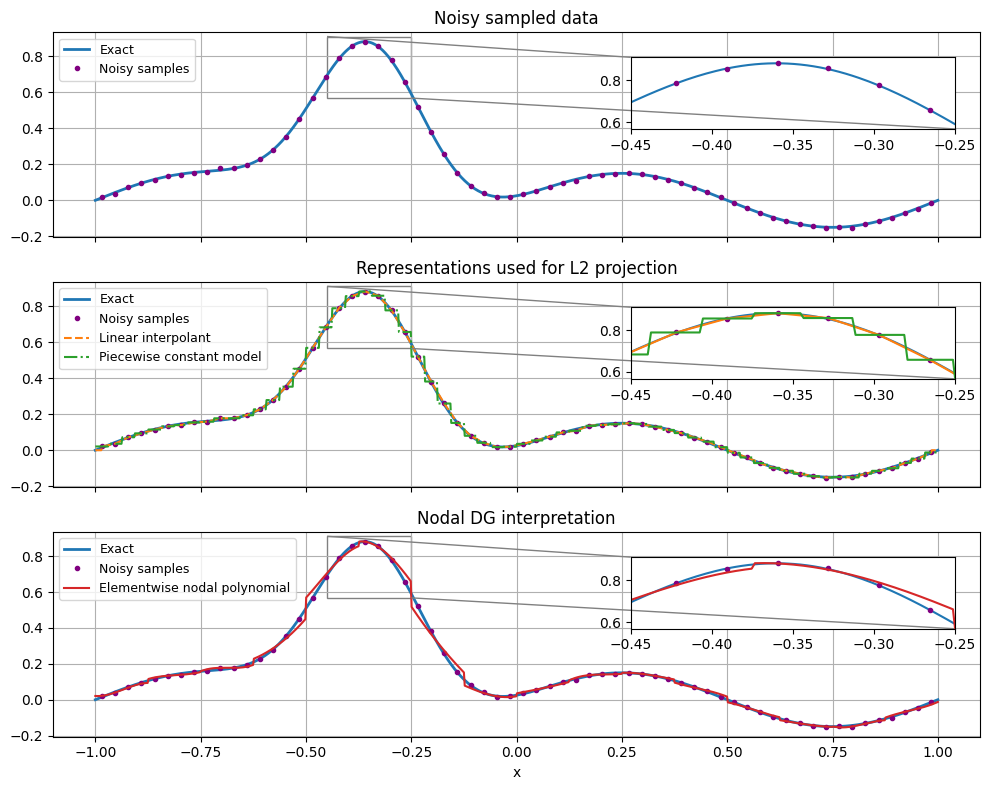

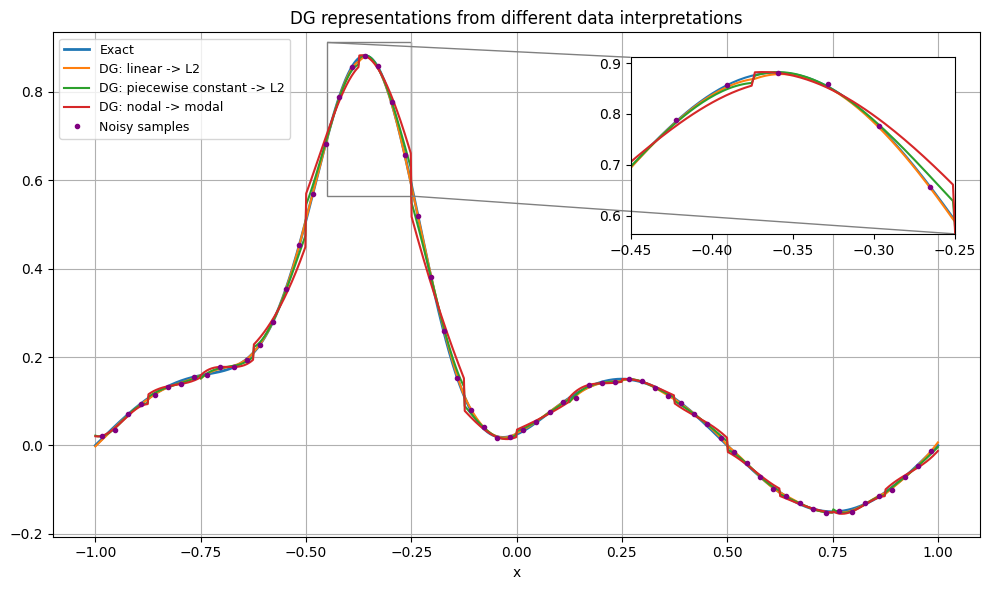

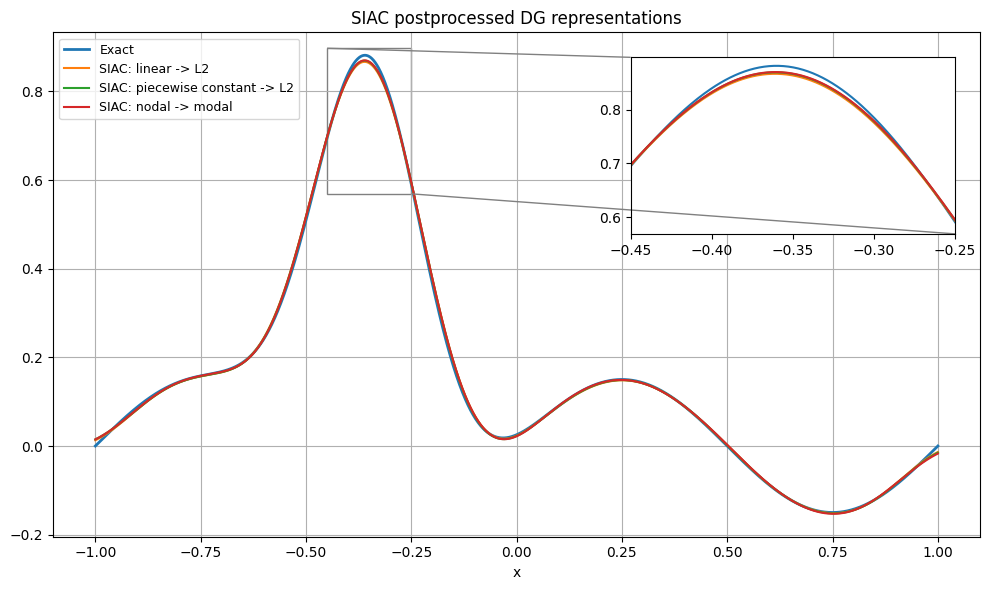

In [87]:
# exact function

gaussian_center = - 0.35

def f_exact2(x):
    #return np.sin(np.pi*x)
    return np.exp(-30.0 * (x - gaussian_center)**2) + 0.15 * np.sin(2*np.pi*x)

# setup
p = 3
K = 16
N = K * (p + 1)
xlim = (-1.0, 1.0)

# noisy data
xgrid, samples_clean, samples_noisy, dx, sigma = make_noisy_samples_1d(
    f_exact2, N, xlim=xlim, deg=p, seed=3, scale_sigma=scale_sigma
)

COLORS = {
    "exact": "tab:blue",
    "samples": "purple",
    "linear": "tab:orange",
    "piecewise": "tab:green",
    "nodal": "tab:red",
}

center_zoom = gaussian_center
offset_zoom = 0.1
zoom = (center_zoom - offset_zoom, center_zoom + offset_zoom)
zoom_location = "upper right"

# figure 1
fig1, axs1 = plot_1d_representations_from_noisy_samples(
    f_exact2,
    samples_noisy,
    COLORS=COLORS,
    xlim=xlim,
    deg=p,
    zoom_xlim=zoom,
    zoom_location=zoom_location
)


fig2, ax2, dg_dict = plot_1d_dg_representations(
    f_exact2,
    samples_noisy,
    COLORS=COLORS,
    xlim=xlim,
    deg=p,
    zoom_xlim=zoom,
    zoom_location=zoom_location
)

fig3, ax3, _ = plot_1d_siac_representations(
    f_exact2,
    dg_dict,
    COLORS=COLORS,
    xlim=xlim,
    zoom_xlim=zoom,
    zoom_location=zoom_location
)

dx = 0.03125
Noise level sigma = 0.003015782985847835


/tmp/ipykernel_61710/1780534351.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/tmp/ipykernel_61710/232270988.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/tmp/ipykernel_61710/1026484494.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


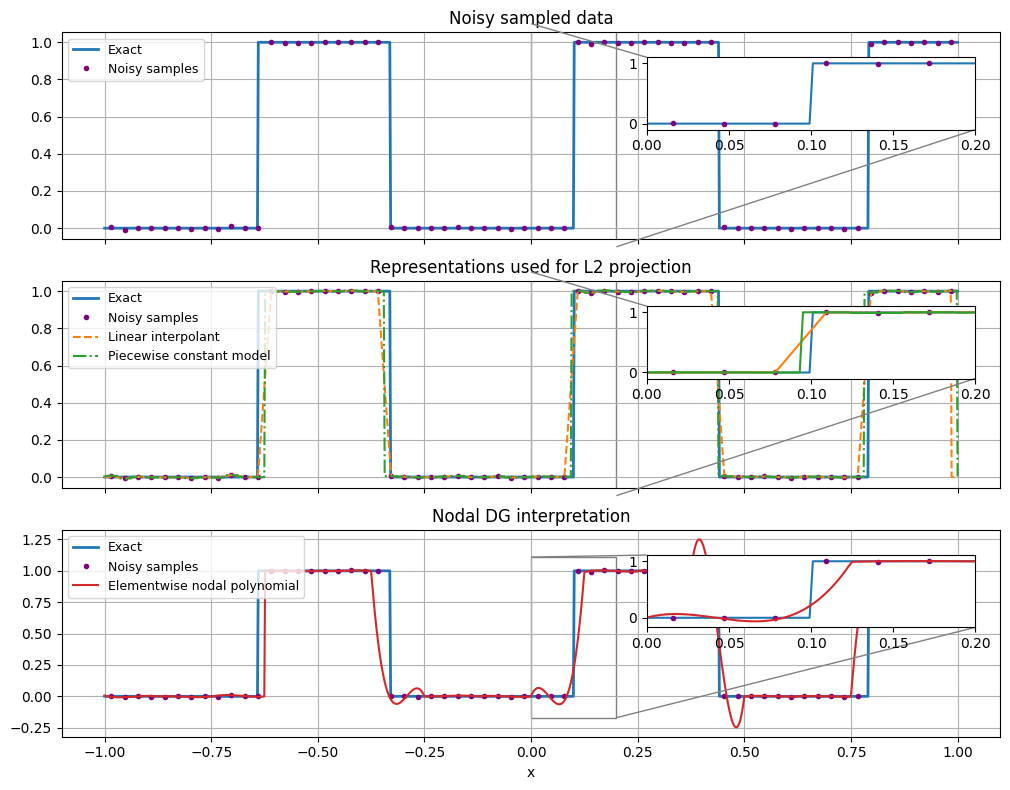

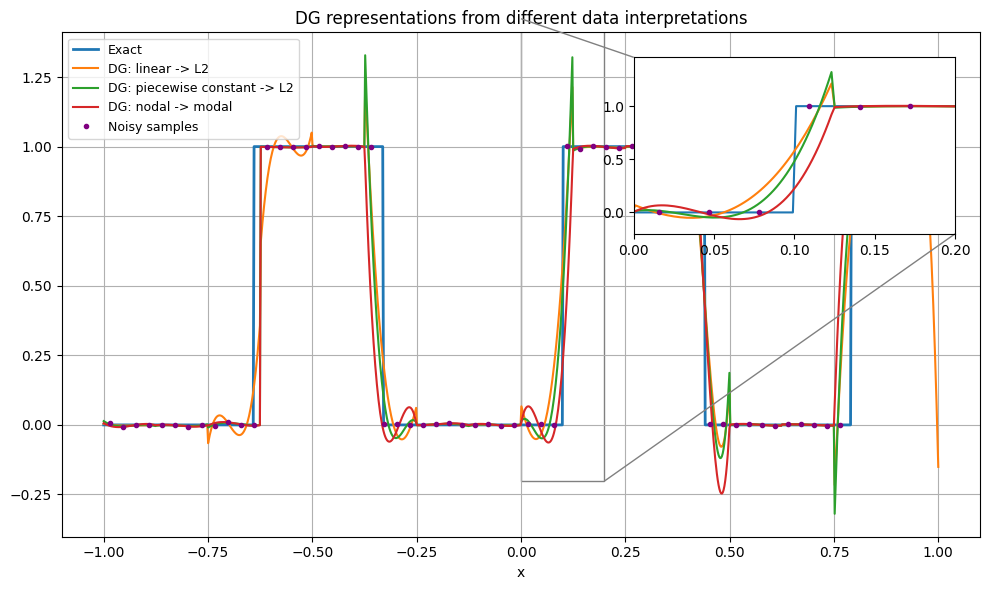

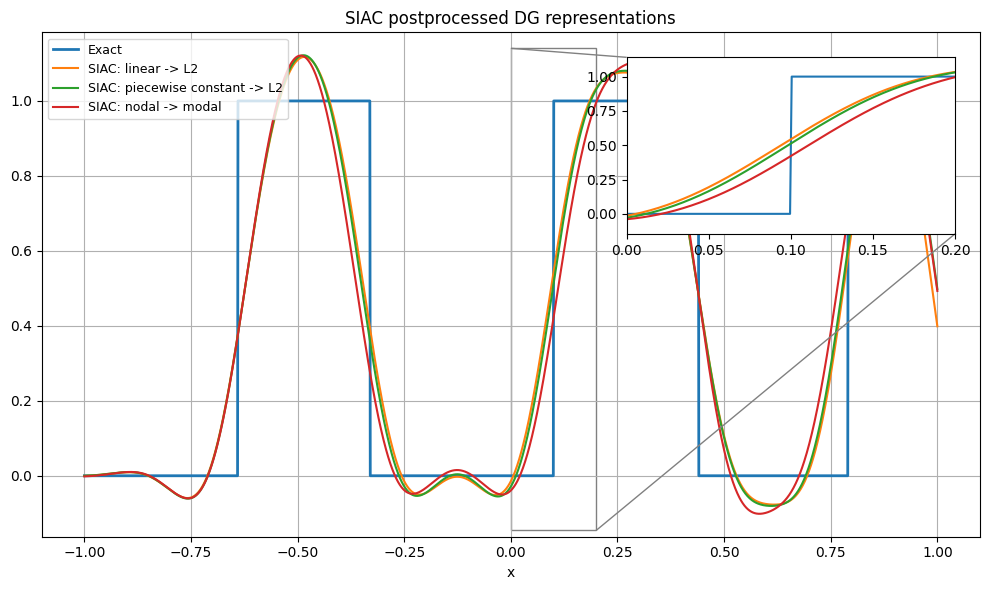

In [89]:
# exact function

def generate_partitioned_cuts(n_cuts=5, domain=(-1.0, 1.0), min_dist=0.1, seed=None, max_tries=1000):
    rng = np.random.default_rng(seed)
    a, b = domain

    if not (a < b):
        raise ValueError("domain must satisfy a < b")
    
    edges = np.linspace(a, b, n_cuts + 2)
    cell_width = edges[1] - edges[0]
    # Necessary condition: even the most favorable configuration cannot fit min_dist
    if min_dist >= 2 * cell_width:
        raise ValueError(
            f"min_dist={min_dist} is too large for this construction. "
            f"Need min_dist < {2*cell_width:.6f}."
        )
    for _ in range(max_tries):
        # one cut in each interior subinterval
        cuts = np.array([
            rng.uniform(edges[i], edges[i + 1])
            for i in range(1, n_cuts + 1)
        ])

        cuts.sort()

        if np.all(np.diff(cuts) >= min_dist):
            return cuts

    raise RuntimeError(
        "Could not generate cuts satisfying min_dist. "
        "Try reducing min_dist or increasing max_tries."
    )
    
        

# step_cuts = generate_partitioned_cuts(n_cuts=3, 
#                                       domain=(-1,1), 
#                                       min_dist=0.4, 
#                                       seed=4)

step_cuts = np.array([-0.64, -0.33, 0.1, 0.44, 0.79])

def f_exact2(x):
    x = np.asarray(x)
    
    # Count how many cuts each x has crossed
    idx = np.sum(x[..., None] >= step_cuts, axis=-1)
    
    # Alternate: 0 → 1 → 0 → 1 ...
    return idx % 2

# setup
p = 3
K = 16
N = K * (p + 1)
xlim = (-1.0, 1.0)

# noisy data
xgrid, samples_clean, samples_noisy, dx, sigma = make_noisy_samples_1d(
    f_exact2, N, xlim=xlim, deg=p, seed=3, scale_sigma=scale_sigma
)

COLORS = {
    "exact": "tab:blue",
    "samples": "purple",
    "linear": "tab:orange",
    "piecewise": "tab:green",
    "nodal": "tab:red",
}

step_cuts = np.asarray(step_cuts)

center_zoom = step_cuts[np.argmin(np.abs(step_cuts))]

offset_zoom = 0.1
zoom = (center_zoom - offset_zoom, center_zoom + offset_zoom)

zoom_location = "upper right"

# figure 1
fig1, axs1 = plot_1d_representations_from_noisy_samples(
    f_exact2,
    samples_noisy,
    COLORS=COLORS,
    xlim=xlim,
    deg=p,
    zoom_xlim=zoom,
    zoom_location=zoom_location
)


fig2, ax2, dg_dict = plot_1d_dg_representations(
    f_exact2,
    samples_noisy,
    COLORS=COLORS,
    xlim=xlim,
    deg=p,
    zoom_xlim=zoom,
    zoom_location=zoom_location
)

fig3, ax3, _ = plot_1d_siac_representations(
    f_exact2,
    dg_dict,
    COLORS=COLORS,
    xlim=xlim,
    zoom_xlim=zoom,
    zoom_location=zoom_location
)